# Conversion rate
### Jimmy Azar

## Introduction

We'll analyze customer conversion rate as a marketing KPI.

The dataset is gathered from a bank marketing campaign based on phone calls to bank clients in the aim of subscribing clients to a term deposit. Conversion in this context is based on whether the client subscribed or not to a term deposit.

## Data exploration

We load and inspect the data. The following is a descriptive summary of the attributes and target variables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# data exploration
path_to_file = '../data/conversion.txt'
data = pd.read_csv(path_to_file)
print(data.head())
print(data.shape)

   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   
3   40     admin.  married     basic.6y       no      no   no  telephone   
4   56   services  married  high.school       no      no  yes  telephone   

  month day_of_week  ...  campaign  pdays  previous     poutcome emp_var_rate  \
0   may         mon  ...         1    999         0  nonexistent          1.1   
1   may         mon  ...         1    999         0  nonexistent          1.1   
2   may         mon  ...         1    999         0  nonexistent          1.1   
3   may         mon  ...         1    999         0  nonexistent          1.1   
4   may         mon  ...         1    999         0  nonexistent          1.1   

   cons_price_idx  cons_conf_idx  euribor3m  nr_employed

## Conversion rates

We transform the conversion variable into a binary numeric variable where 1 represents "yes" and 0 represents "no". Then, we compute the total number of conversions out of all responses, and indicate the overall conversion rate as a percentage.

In [2]:
# conversion rates
data['y'] = data['y'].apply(lambda x: 1 if x=='yes' else 0)

print(data['y'].sum()/data['y'].count() * 100)

values, counts = np.unique(data['y'], return_counts=True)
dict(zip(values,counts))

11.265417111780131


{0: 36548, 1: 4640}

### By number of contacts

We'll analyze conversion as a function of the number of contacts conducted by the bank.

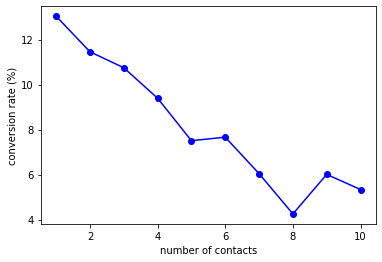

In [3]:
# by number of contacts
df = data.groupby(['campaign']).aggregate({'campaign': 'count', 'y': 'sum'})
df.rename(columns={'campaign': 'count', 'y': 'n_conversions'}, inplace=True)
df['conversion_rate'] = df['n_conversions']/df['count'] * 100

plt.plot(df.index.values[:10], df['conversion_rate'].values[:10], c='b')
plt.scatter(df.index.values[:10], df['conversion_rate'].values[:10], c='b')
plt.xlabel('number of contacts')
plt.ylabel('conversion rate (%)')
plt.show()

### By age

Let's now study the conversion rate as a function of age. We generate a plot showing the percentage conversion rate as a function of age.

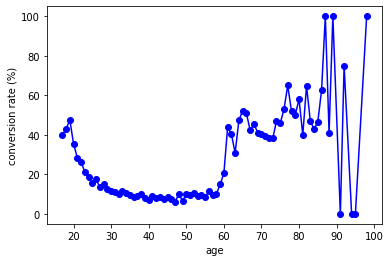

In [4]:
# by age
df = data.groupby(['age']).aggregate({'age': 'count', 'y': 'sum'})
df.rename(columns={'age': 'count', 'y': 'n_conversions'}, inplace=True)
df['conversion_rate'] = df['n_conversions']/df['count'] * 100

plt.plot(df.index, df['conversion_rate'], c='b') 
plt.scatter(df.index, df['conversion_rate'], c='b')
plt.xlabel('age')
plt.ylabel('conversion rate (%)')
plt.show()

### By age group 

Notably, the conversion rate values are not very stable for high age. This is due to the fact that the sample size (number of clients) becomes small for high ages. Therefore, to reduce noise, we'll set up age groups and create a bar plot showing the conversion rate for each group.

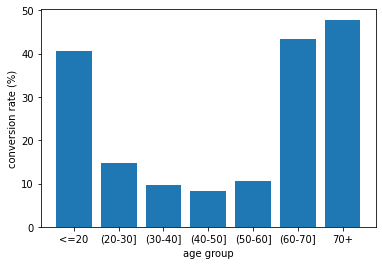

In [5]:
# by age group
data['age_group'] =  data['age'].apply(lambda x: '<=20' if x<=20            \
                                         else '(20-30]' if (x>20 and x<=30) \
                                         else '(30-40]' if (x>30 and x<=40) \
                                         else '(40-50]' if (x>40 and x<=50) \
                                         else '(50-60]' if (x>50 and x<=60) \
                                         else '(60-70]' if (x>60 and x<=70) \
                                         else '70+')

df = data.groupby(['age_group']).aggregate({'age_group': 'count', 'y': 'sum'})
df.rename(columns={'age_group': 'count', 'y': 'n_conversions'}, inplace=True)
df['conversion_rate'] = df['n_conversions']/df['count'] * 100

#re-order for bar ploy
df = df.reindex(['<=20','(20-30]','(30-40]','(40-50]','(50-60]','(60-70]','70+'])

plt.bar(df.index, df['conversion_rate']) 
plt.xlabel('age group')
plt.ylabel('conversion rate (%)')
plt.show()

### By marital status

We'll create a pie chart showing the percentage conversion rate as a function of marital status.

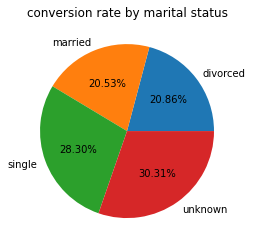

In [6]:
# by marital status
df = data.groupby(['marital']).aggregate({'marital': 'count', 'y': 'sum'})
df.rename(columns={'marital': 'count', 'y': 'n_conversions'}, inplace=True)
df['conversion_rate'] = df['n_conversions']/df['count'] * 100

plt.pie(df['conversion_rate'], labels=df.index, autopct='%0.2f%%') 
plt.title('conversion rate by marital status')
plt.show()

### By education

We also create a pie chart showing the percentage conversion rate as a function of education.

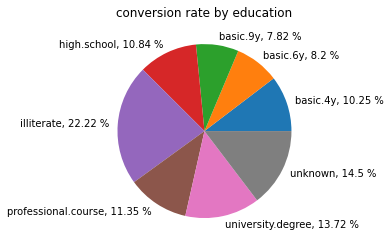

In [7]:
# by education
df = data.groupby(['education']).aggregate({'education': 'count', 'y': 'sum'})
df.rename(columns={'education': 'count', 'y': 'n_conversions'}, inplace=True)
df['conversion_rate'] = df['n_conversions']/df['count'] * 100

labels = [f'{i}, {j} %' for i, j in zip(df.index.values, df['conversion_rate'].values.round(2))] 

plt.pie(df['conversion_rate'], labels=labels)
plt.title('conversion rate by education')
plt.show()

### By job

We'll create a horizontal bar plot showing the percentage conversion rate as a function of job type.

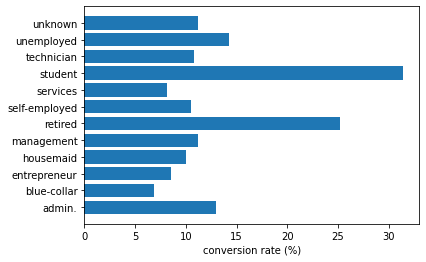

In [8]:
# by job
df = data.groupby(['job']).aggregate({'job': 'count', 'y': 'sum'})
df.rename(columns={'job': 'count', 'y': 'n_conversions'}, inplace=True)
df['conversion_rate'] = df['n_conversions']/df['count'] * 100

plt.barh(df.index, df['conversion_rate']) 
plt.xlabel("conversion rate (%)")
plt.show()

## Duration of last contact 

We compute the duration (in hours) of the last contact with the bank for each client. Note that the duration in the dataset is originally provided in seconds. We create two horizontal box plots in the same figure summarizing the spread of the duration values for the case of conversions and non-conversions.

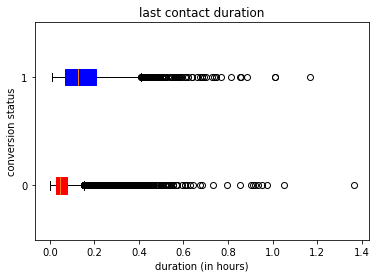

In [9]:
# duration of last contact

h = plt.boxplot([data.loc[data['y']==0,'duration']/3600, data.loc[data['y']==1,'duration']/3600], labels=[0, 1], patch_artist=True, vert=False)
plt.xlabel('duration (in hours)')
plt.ylabel('conversion status')
plt.title('last contact duration')
plt.setp(h["boxes"][0], color="red")
plt.setp(h['boxes'][1], color="blue")
plt.show() 

## Logistic regression

We'll build a logistic regression model for predicting conversion (0 or 1) from the attributes: "age", "campaign" (number of contacts), "previous", "marital", "job", and "housing". We first transform categorical variables by one-hot-encoding.

We sort and inspect the model coefficients to see which attributes are positively or negatively correlated with conversion.

In [10]:
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# logistic regression
df_categorical = pd.get_dummies(data[['marital','job','housing']])
df = pd.concat([df_categorical, data[['age','campaign','previous']]], axis=1)

X = df.copy()
y = data['y']

model = LogisticRegression(solver='lbfgs').fit(X, y)
y_pred = model.predict(X)

model.score(X, y) #accuracy
model.coef_
model.intercept_

df = pd.DataFrame(model.coef_[0], index=X.columns.tolist(), columns=['coefficients'])

df.loc[df['coefficients']>0]
df.loc[df['coefficients']<0]

df.sort_values(by=['coefficients'], ascending=True)

,coefficients
job_blue-collar,-0.625491
marital_divorced,-0.553651
job_services,-0.544678
marital_married,-0.491123
housing_unknown,-0.470781
job_entrepreneur,-0.434496
housing_no,-0.421617
housing_yes,-0.388527
job_self-employed,-0.248418
job_housemaid,-0.232108
